# Dataset audit and exploratory analysis

**Predictive Maintenance & Equipment Failure Early Warning Platform — Milestones 1 and 2**

Run all cells from a fresh Python kernel, in order. Select the project `.venv` environment. This notebook contains all analysis implementations; it does not import project Python modules. It reads the immutable CSV, writes measured audit and EDA reports, and displays all six figures. No model is trained and no preprocessing or split is fitted.

Dependencies are listed in `requirements-dev.txt`. Open the notebook from the project root or `notebooks/`. Run `02_validation_checks.ipynb` for the 22 validation checks.

AI4I is synthetic. [Dataset citation and license](https://doi.org/10.24432/C5HS5C); [Kaggle source](https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020). Labels describe failure at an observation, without establishing a future warning horizon.

Project format: data preparation, model training, visualization, and evaluation use notebooks. Production inference, backend, and frontend will use ordinary source files in their later milestones.

## 1. Imports, paths, and explicit column roles

The candidate feature allowlist excludes identifiers and all failure-state flags. Seed 42 is reserved for future reproducible experiments; this descriptive analysis uses no randomness.

In [1]:
import csv
import hashlib
import json

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter
from IPython.display import Image, Markdown, display

In [2]:
from pathlib import Path

PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "data" / "raw" / "ai4i2020.csv").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Open this notebook from the project folder or its notebooks directory")
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "ai4i2020.csv"
REPORT_DIR = PROJECT_ROOT / "reports"
RANDOM_STATE = 42

TARGET_COLUMN = "Machine failure"
IDENTIFIER_COLUMNS = ("UDI", "Product ID")
CATEGORICAL_COLUMNS = ("Type",)
NUMERIC_COLUMNS = (
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
)
FEATURE_COLUMNS = CATEGORICAL_COLUMNS + NUMERIC_COLUMNS
FAILURE_COLUMNS = ("TWF", "HDF", "PWF", "OSF", "RNF")
EXPECTED_COLUMNS = IDENTIFIER_COLUMNS + FEATURE_COLUMNS + (TARGET_COLUMN,) + FAILURE_COLUMNS
MACHINE_TYPES = ("L", "M", "H")

FIGURE_DIR = REPORT_DIR / "figures"
NORMAL_COLOR = "#287c9b"
FAILURE_COLOR = "#b64732"
SENSOR_NAMES = ("Air temperature", "Process temperature", "Rotational speed", "Torque", "Tool wear")

## 2. Load and validate the actual CSV

Accept the UTF-8 byte-order mark without modifying the file. Validate schema and values; preserve label inconsistencies for inspection.

In [3]:
def validate_dataset(frame: pd.DataFrame) -> None:
    """Validate the raw training schema without changing values or labels."""
    missing = sorted(set(EXPECTED_COLUMNS) - set(frame.columns))
    unexpected = sorted(set(frame.columns) - set(EXPECTED_COLUMNS))
    if missing:
        raise ValueError(f"Missing required columns: {', '.join(missing)}")
    if unexpected:
        raise ValueError(f"Unexpected columns: {', '.join(unexpected)}")
    if frame.columns.duplicated().any():
        raise ValueError("Duplicate column names are not allowed")
    if frame.empty:
        raise ValueError("Dataset contains no records")
    null_columns = frame.columns[frame.isna().any()].tolist()
    if null_columns:
        raise ValueError(f"Missing values in columns: {', '.join(null_columns)}")
    if not frame["Type"].isin(MACHINE_TYPES).all():
        raise ValueError("Type must be one of: L, M, H")
    if not frame["Product ID"].map(lambda value: isinstance(value, str) and bool(value.strip())).all():
        raise ValueError("Product ID must contain nonempty strings")

    for column in ("UDI",) + NUMERIC_COLUMNS + (TARGET_COLUMN,) + FAILURE_COLUMNS:
        values = frame[column]
        if not pd.api.types.is_numeric_dtype(values) or pd.api.types.is_bool_dtype(values):
            raise ValueError(f"Column must be numeric: {column}")
        if not np.isfinite(values.to_numpy(dtype=float)).all():
            raise ValueError(f"Column contains nonfinite values: {column}")
    for column in (TARGET_COLUMN,) + FAILURE_COLUMNS:
        if not frame[column].isin([0, 1]).all():
            raise ValueError(f"Column must contain only 0 or 1: {column}")
    for column in ("UDI", "Rotational speed [rpm]", "Tool wear [min]"):
        if (frame[column] % 1 != 0).any():
            raise ValueError(f"Column must contain whole numbers: {column}")
    for column in ("UDI",) + NUMERIC_COLUMNS:
        invalid = frame[column] < 0 if column == "Tool wear [min]" else frame[column] <= 0
        if invalid.any():
            raise ValueError(f"Column contains invalid nonpositive or negative readings: {column}")

In [4]:
def load_dataset(path: Path = RAW_DATA_PATH) -> pd.DataFrame:
    """Read the supplied UTF-8 CSV, accepting its byte-order mark."""
    with path.open(encoding="utf-8-sig", newline="") as source:
        header = next(csv.reader(source), [])
    if not header:
        raise ValueError("CSV is empty")
    if len(header) != len(set(header)):
        raise ValueError("Duplicate column names are not allowed")
    frame = pd.read_csv(path, encoding="utf-8-sig")
    validate_dataset(frame)
    return frame

In [5]:
source_hash_before = hashlib.sha256(RAW_DATA_PATH.read_bytes()).hexdigest()
frame = load_dataset()
original_frame = frame.copy(deep=True)
print(f"Loaded {frame.shape[0]:,} rows and {frame.shape[1]} columns")
display(frame.head())

Loaded 10,000 rows and 14 columns


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Reproducible dataset audit

Report actual schema, missingness, duplicates, cardinalities, distributions, descriptive statistics, label overlap, and potential outliers. No readings or labels are removed or rewritten.

In [6]:
def build_audit(frame: pd.DataFrame) -> dict:
    """Summarize observed data; flag unusual rows without removing them."""
    validate_dataset(frame)
    flags = frame[list(FAILURE_COLUMNS)]
    active_count = flags.sum(axis=1)
    combinations = flags.apply(
        lambda row: "+".join(label for label in FAILURE_COLUMNS if row[label] == 1) or "none",
        axis=1,
    )
    outliers = {}
    for column in NUMERIC_COLUMNS:
        values = frame[column]
        q1, q3 = values.quantile([0.25, 0.75])
        lower, upper = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
        outliers[column] = {
            "lower_fence": float(lower),
            "upper_fence": float(upper),
            "count": int(((values < lower) | (values > upper)).sum()),
        }
    columns = {}
    for column in frame:
        unique = frame[column].drop_duplicates().sort_values()
        columns[column] = {
            "dtype": str(frame[column].dtype),
            "missing": int(frame[column].isna().sum()),
            "unique_count": int(unique.size),
            "unique_values_or_first_ten": unique.head(10).tolist(),
        }
    return {
        "shape": list(frame.shape),
        "columns": columns,
        "duplicate_rows": int(frame.duplicated().sum()),
        "duplicate_feature_rows": int(frame.duplicated(subset=list(FEATURE_COLUMNS)).sum()),
        "duplicate_identifiers": {c: int(frame[c].duplicated().sum()) for c in IDENTIFIER_COLUMNS},
        "udi_is_sequential": frame["UDI"].tolist() == list(range(1, len(frame) + 1)),
        "product_prefix_type_mismatches": int((frame["Product ID"].str[0] != frame["Type"]).sum()),
        "target_counts": frame[TARGET_COLUMN].value_counts().sort_index().to_dict(),
        "failure_rate": float(frame[TARGET_COLUMN].mean()),
        "machine_type_counts": frame["Type"].value_counts().sort_index().to_dict(),
        "numeric_statistics": frame[list(NUMERIC_COLUMNS)].describe().to_dict(),
        "failure_type_counts": flags.sum().to_dict(),
        "failure_label_combinations": combinations.value_counts().to_dict(),
        "rows_with_multiple_failure_labels": int((active_count > 1).sum()),
        "failure_without_type_udi": frame.loc[(frame[TARGET_COLUMN] == 1) & (active_count == 0), "UDI"].tolist(),
        "type_without_failure_udi": frame.loc[(frame[TARGET_COLUMN] == 0) & (active_count > 0), "UDI"].tolist(),
        "potential_outliers_iqr": outliers,
    }

In [7]:
def render_markdown(audit: dict) -> str:
    lines = [
        "# Dataset audit", "",
        f"Source: `{audit['source']}`. SHA-256: `{audit['sha256']}`.", "",
        f"Shape: {audit['shape'][0]:,} rows × {audit['shape'][1]} columns. Schema validation passed.",
        f"Duplicate complete rows: {audit['duplicate_rows']}; duplicate feature rows: {audit['duplicate_feature_rows']}.",
        "", "## Columns", "",
        "Unique values are listed in full for up to ten values; otherwise the first ten sorted values are shown.", "",
        "| Column | Inferred dtype | Missing | Unique | Values / sample |",
        "| --- | --- | ---: | ---: | --- |",
    ]
    for name, info in audit["columns"].items():
        lines.append(f"| {name} | {info['dtype']} | {info['missing']} | {info['unique_count']} | {info['unique_values_or_first_ten']} |")
    lines += ["", "## Distributions", "", f"Failure rate: {audit['failure_rate']:.2%}.", ""]
    for key in ("target_counts", "machine_type_counts", "failure_type_counts", "failure_label_combinations"):
        lines += [f"### {key.replace('_', ' ').capitalize()}", "", "| Value | Count |", "| --- | ---: |"]
        lines.extend(f"| {value} | {count} |" for value, count in audit[key].items())
        lines.append("")
    lines += ["## Sensor statistics", "", "| Sensor | Count | Mean | Std | Min | 25% | Median | 75% | Max |", "| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |"]
    for column, stats in audit["numeric_statistics"].items():
        numbers = " | ".join(f"{stats[key]:.3f}" for key in ("count", "mean", "std", "min", "25%", "50%", "75%", "max"))
        lines.append(f"| {column} | {numbers} |")
    lines += ["", "## Potential outliers", "", "Tukey fences (Q1 − 1.5 × IQR, Q3 + 1.5 × IQR) flag unusual readings, not invalid records. No rows were removed.", "", "| Sensor | Lower fence | Upper fence | Flagged rows |", "| --- | ---: | ---: | ---: |"]
    for column, result in audit["potential_outliers_iqr"].items():
        lines.append(f"| {column} | {result['lower_fence']:.3f} | {result['upper_fence']:.3f} | {result['count']} |")
    lines += [
        "", "## Identifier and label checks", "",
        f"- Duplicate identifiers: {audit['duplicate_identifiers']}.",
        f"- UDI is sequential from 1: {audit['udi_is_sequential']}.",
        f"- Product ID prefix / Type mismatches: {audit['product_prefix_type_mismatches']}.",
        f"- Rows with overlapping failure labels: {audit['rows_with_multiple_failure_labels']}.",
        f"- Machine failure = 1 with no failure type (UDI): {audit['failure_without_type_udi']}.",
        f"- Machine failure = 0 with a failure type (UDI): {audit['type_without_failure_udi']}.",
        "", "Interpretation and feature decisions are recorded in [milestone_1.md](milestone_1.md).", "",
    ]
    return "\n".join(lines)

In [8]:
audit = build_audit(frame)
audit["source"] = "data/raw/ai4i2020.csv"
audit["sha256"] = source_hash_before
audit["runtime"] = {"pandas": pd.__version__}
REPORT_DIR.mkdir(parents=True, exist_ok=True)
(REPORT_DIR / "dataset_audit.json").write_text(json.dumps(audit, indent=2, allow_nan=False) + "\n", encoding="utf-8")
(REPORT_DIR / "dataset_audit.md").write_text(render_markdown(audit), encoding="utf-8")
display(Markdown(render_markdown(audit).replace("(milestone_1.md)", "(../reports/milestone_1.md)")))

# Dataset audit

Source: `data/raw/ai4i2020.csv`. SHA-256: `dc6630cd9b1f0f853922fad78a1b6436570d3f1ec863f1dd5c4340ac56bc8a8e`.

Shape: 10,000 rows × 14 columns. Schema validation passed.
Duplicate complete rows: 0; duplicate feature rows: 0.

## Columns

Unique values are listed in full for up to ten values; otherwise the first ten sorted values are shown.

| Column | Inferred dtype | Missing | Unique | Values / sample |
| --- | --- | ---: | ---: | --- |
| UDI | int64 | 0 | 10000 | [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] |
| Product ID | str | 0 | 10000 | ['H29424', 'H29425', 'H29432', 'H29434', 'H29441', 'H29452', 'H29457', 'H29462', 'H29466', 'H29481'] |
| Type | str | 0 | 3 | ['H', 'L', 'M'] |
| Air temperature [K] | float64 | 0 | 93 | [295.3, 295.4, 295.5, 295.6, 295.7, 295.8, 295.9, 296.0, 296.1, 296.2] |
| Process temperature [K] | float64 | 0 | 82 | [305.7, 305.8, 305.9, 306.0, 306.1, 306.2, 306.3, 306.4, 306.5, 306.6] |
| Rotational speed [rpm] | int64 | 0 | 941 | [1168, 1181, 1183, 1192, 1200, 1202, 1207, 1208, 1212, 1217] |
| Torque [Nm] | float64 | 0 | 577 | [3.8, 4.2, 4.6, 5.6, 5.8, 8.0, 8.8, 9.3, 9.7, 9.8] |
| Tool wear [min] | int64 | 0 | 246 | [0, 2, 3, 4, 5, 6, 7, 8, 9, 10] |
| Machine failure | int64 | 0 | 2 | [0, 1] |
| TWF | int64 | 0 | 2 | [0, 1] |
| HDF | int64 | 0 | 2 | [0, 1] |
| PWF | int64 | 0 | 2 | [0, 1] |
| OSF | int64 | 0 | 2 | [0, 1] |
| RNF | int64 | 0 | 2 | [0, 1] |

## Distributions

Failure rate: 3.39%.

### Target counts

| Value | Count |
| --- | ---: |
| 0 | 9661 |
| 1 | 339 |

### Machine type counts

| Value | Count |
| --- | ---: |
| H | 1003 |
| L | 6000 |
| M | 2997 |

### Failure type counts

| Value | Count |
| --- | ---: |
| TWF | 46 |
| HDF | 115 |
| PWF | 95 |
| OSF | 98 |
| RNF | 19 |

### Failure label combinations

| Value | Count |
| --- | ---: |
| none | 9652 |
| HDF | 106 |
| PWF | 80 |
| OSF | 78 |
| TWF | 42 |
| RNF | 18 |
| PWF+OSF | 11 |
| HDF+OSF | 6 |
| HDF+PWF | 3 |
| TWF+OSF | 2 |
| TWF+RNF | 1 |
| TWF+PWF+OSF | 1 |

## Sensor statistics

| Sensor | Count | Mean | Std | Min | 25% | Median | 75% | Max |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Air temperature [K] | 10000.000 | 300.005 | 2.000 | 295.300 | 298.300 | 300.100 | 301.500 | 304.500 |
| Process temperature [K] | 10000.000 | 310.006 | 1.484 | 305.700 | 308.800 | 310.100 | 311.100 | 313.800 |
| Rotational speed [rpm] | 10000.000 | 1538.776 | 179.284 | 1168.000 | 1423.000 | 1503.000 | 1612.000 | 2886.000 |
| Torque [Nm] | 10000.000 | 39.987 | 9.969 | 3.800 | 33.200 | 40.100 | 46.800 | 76.600 |
| Tool wear [min] | 10000.000 | 107.951 | 63.654 | 0.000 | 53.000 | 108.000 | 162.000 | 253.000 |

## Potential outliers

Tukey fences (Q1 − 1.5 × IQR, Q3 + 1.5 × IQR) flag unusual readings, not invalid records. No rows were removed.

| Sensor | Lower fence | Upper fence | Flagged rows |
| --- | ---: | ---: | ---: |
| Air temperature [K] | 293.500 | 306.300 | 0 |
| Process temperature [K] | 305.350 | 314.550 | 0 |
| Rotational speed [rpm] | 1139.500 | 1895.500 | 418 |
| Torque [Nm] | 12.800 | 67.200 | 69 |
| Tool wear [min] | -110.500 | 325.500 | 0 |

## Identifier and label checks

- Duplicate identifiers: {'UDI': 0, 'Product ID': 0}.
- UDI is sequential from 1: True.
- Product ID prefix / Type mismatches: 0.
- Rows with overlapping failure labels: 24.
- Machine failure = 1 with no failure type (UDI): [1438, 2750, 4045, 4685, 5537, 5942, 6479, 8507, 9016].
- Machine failure = 0 with a failure type (UDI): [1222, 1303, 1749, 2073, 2560, 3066, 3453, 5472, 5490, 5496, 5510, 5554, 5640, 6092, 6914, 6961, 7489, 7869].

Interpretation and feature decisions are recorded in [milestone_1.md](../reports/milestone_1.md).


### Initial formulation and audit decisions

Use `Machine failure` as the binary target, `Type` as a categorical input, and five sensor measurements as numeric inputs. Exclude UDI and Product ID: both are unique; UDI follows row order and the Product ID prefix duplicates Type. Exclude TWF, HDF, PWF, OSF, and RNF because they describe failure states.

There are 24 rows with overlapping flags, so a future failure-type component requires a separate multilabel formulation. Nine primary failures have no failure flag; 18 normal labels have an RNF flag. Preserve these discrepancies. IQR outliers are review flags, not deletion criteria.

## 4. Numerical EDA summaries

Within-group rates use each group’s own support. Quintile boundaries are exploratory only, and tied values remain together. CSV position is not a timestamp.

In [9]:
def failure_rates(frame: pd.DataFrame, groups: pd.Series) -> pd.DataFrame:
    rates = frame.groupby(groups, observed=True)[TARGET_COLUMN].agg(records="size", failures="sum")
    rates["failure_rate"] = rates["failures"] / rates["records"]
    return rates

In [10]:
def sensor_bins(frame: pd.DataFrame, column: str) -> pd.DataFrame:
    """Describe empirical quintiles; tied readings stay in the same bin."""
    bins = pd.qcut(frame[column], q=5, duplicates="drop")
    rates = failure_rates(frame, bins)
    ranges = frame.groupby(bins, observed=True)[column].agg(minimum="min", maximum="max")
    return rates.join(ranges).reset_index(drop=True)

In [11]:
def build_summary(frame: pd.DataFrame) -> dict:
    validate_dataset(frame)
    flags = frame[list(FAILURE_COLUMNS)].astype(int)
    # Positions retain supplied CSV order; UDI is never used as a model feature.
    blocks = pd.Series(np.arange(len(frame)) // 1000 + 1, index=frame.index, name="block")
    block_rates = failure_rates(frame, blocks)
    block_rates["first_row"] = (block_rates.index - 1) * 1000 + 1
    block_rates["last_row"] = np.minimum(block_rates.index * 1000, len(frame))
    block_rates = block_rates.join(flags.groupby(blocks).sum())
    sensor_stats = frame.groupby(TARGET_COLUMN)[list(NUMERIC_COLUMNS)].agg(["mean", "median", "std"])
    correlations = frame[[*NUMERIC_COLUMNS, TARGET_COLUMN]].corr()
    lag_one = {column: float(frame[column].autocorr(lag=1)) for column in NUMERIC_COLUMNS}
    outlier_rates = {}
    for column in NUMERIC_COLUMNS:
        q1, q3 = frame[column].quantile([0.25, 0.75])
        outlier = (frame[column] < q1 - 1.5 * (q3 - q1)) | (frame[column] > q3 + 1.5 * (q3 - q1))
        outlier_rates[column] = failure_rates(frame, outlier.rename("outside_iqr_fences")).reset_index().to_dict("records")
    support = pd.DataFrame({
        "positive_flags": flags.sum(),
        "with_primary_failure": flags.loc[frame[TARGET_COLUMN] == 1].sum(),
        "without_primary_failure": flags.loc[frame[TARGET_COLUMN] == 0].sum(),
    })
    return {
        "records": len(frame),
        "target_counts": frame[TARGET_COLUMN].value_counts().sort_index().to_dict(),
        "overall_failure_rate": float(frame[TARGET_COLUMN].mean()),
        "machine_types": failure_rates(frame, frame["Type"]).reset_index().to_dict("records"),
        "sensor_statistics_by_target": {
            column: sensor_stats[column].reset_index().to_dict("records") for column in NUMERIC_COLUMNS
        },
        "sensor_quintiles": {column: sensor_bins(frame, column).to_dict("records") for column in NUMERIC_COLUMNS},
        "pearson_correlations": correlations.to_dict(),
        "lag_one_correlations_in_csv_order": lag_one,
        "row_blocks": block_rates.reset_index().to_dict("records"),
        "failure_label_support": support.to_dict("index"),
        "failure_label_cooccurrence": (flags.T @ flags).to_dict(),
        "outlier_failure_rates": outlier_rates,
    }

In [12]:
summary = build_summary(frame)
summary["source_sha256"] = source_hash_before
summary["runtime"] = {"pandas": pd.__version__, "numpy": np.__version__, "matplotlib": matplotlib.__version__}
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
(REPORT_DIR / "eda_summary.json").write_text(json.dumps(summary, indent=2, allow_nan=False) + "\n", encoding="utf-8")
display(pd.DataFrame(summary["machine_types"]))
display(pd.DataFrame(summary["row_blocks"]))

,Type,records,failures,failure_rate
0,H,1003,21,0.020937
1,L,6000,235,0.039167
2,M,2997,83,0.027694


,block,records,failures,failure_rate,first_row,last_row,TWF,HDF,PWF,OSF,RNF
0,1,1000,23,0.023,1,1000,1,0,13,10,0
1,2,1000,29,0.029,1001,2000,5,0,13,12,3
2,3,1000,22,0.022,2001,3000,5,0,8,8,2
3,4,1000,27,0.027,3001,4000,4,7,9,9,3
4,5,1000,134,0.134,4001,5000,6,108,15,12,0
5,6,1000,20,0.020,5001,6000,5,0,8,9,6
6,7,1000,23,0.023,6001,7000,5,0,10,8,3
7,8,1000,22,0.022,7001,8000,5,0,9,9,2
8,9,1000,17,0.017,8001,9000,6,0,5,7,0
9,10,1000,22,0.022,9001,10000,4,0,5,14,0


## 5. Figures and interpretation

Figures are saved as PNGs and embedded below. The plotting functions use only the supplied data and computed summaries.

In [13]:
def save_figure(figure: plt.Figure, name: str) -> None:
    figure.savefig(FIGURE_DIR / f"{name}.png", dpi=160, facecolor="white")
    plt.close(figure)

### Target imbalance and machine type

In [14]:
def plot_overview(summary: dict) -> None:
    figure, axes = plt.subplots(1, 3, figsize=(14, 4.5), layout="constrained")
    figure.suptitle("Failure prevalence and machine type", fontsize=16)
    counts = [summary["target_counts"].get(label, 0) for label in (0, 1)]
    bars = axes[0].bar(["Normal", "Failure"], counts, color=[NORMAL_COLOR, FAILURE_COLOR])
    axes[0].bar_label(bars, labels=[f"{n:,}\n{n / summary['records']:.2%}" for n in counts], padding=4)
    axes[0].set(title="Primary target", ylabel="Records", ylim=(0, max(counts) * 1.23))
    types = pd.DataFrame(summary["machine_types"]).set_index("Type").loc[["L", "M", "H"]]
    bars = axes[1].bar(types.index, types["records"], color=NORMAL_COLOR)
    axes[1].bar_label(bars, padding=4)
    axes[1].set(title="Type support", ylabel="Records", ylim=(0, types["records"].max() * 1.2))
    bars = axes[2].bar(types.index, types["failure_rate"], color=FAILURE_COLOR)
    axes[2].bar_label(bars, labels=[f"{r.failure_rate:.2%}\n{int(r.failures)} failures" for r in types.itertuples()], padding=4, bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.5})
    axes[2].axhline(summary["overall_failure_rate"], color="#555555", linestyle="--", label="Overall rate")
    axes[2].set(title="Within-type failure rate", ylabel="Observed failure rate", ylim=(0, 0.06))
    axes[2].yaxis.set_major_formatter(PercentFormatter(1))
    axes[2].legend(loc="upper right", fontsize=8)
    save_figure(figure, "eda_overview")

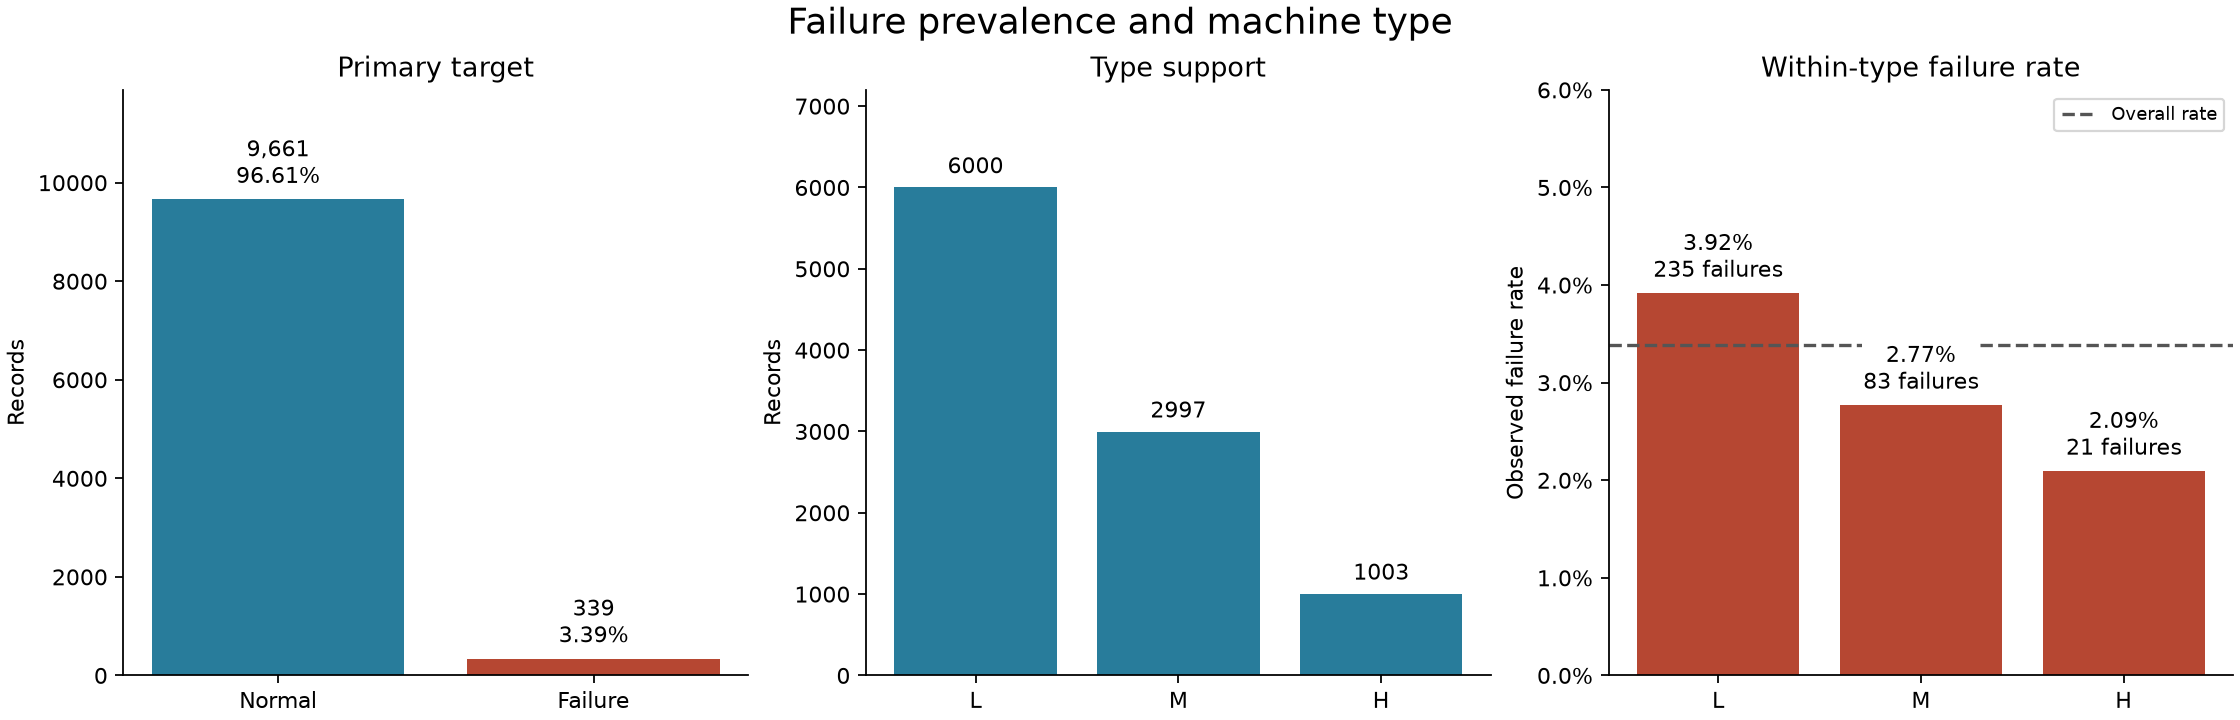

In [15]:
with plt.rc_context({"font.family": "DejaVu Sans", "axes.spines.top": False, "axes.spines.right": False, "font.size": 10}):
    plot_overview(summary)
display(Image(filename=str(FIGURE_DIR / "eda_overview.png")))

Failures account for 3.39% of observations. Within-type rates are L 3.92%, M 2.77%, and H 2.09%. These are descriptive associations; type H has only 21 failures. Accuracy alone would obscure poor failure detection.

### Sensor distributions and failure relationships

In [16]:
def plot_sensors(frame: pd.DataFrame, summary: dict) -> None:
    figure, axes = plt.subplots(5, 2, figsize=(13, 16), layout="constrained")
    figure.suptitle("Sensor distributions and observed failure rates\nHistograms normalize each class separately; quintiles retain tied readings\nBar labels = failures / records; dashed line = overall failure rate", fontsize=14)
    for row, column in enumerate(NUMERIC_COLUMNS):
        histogram, rates_ax = axes[row]
        edges = np.histogram_bin_edges(frame[column], bins=30)
        for label, color, name in ((0, NORMAL_COLOR, "Normal"), (1, FAILURE_COLOR, "Failure")):
            values = frame.loc[frame[TARGET_COLUMN] == label, column]
            histogram.hist(values, bins=edges, weights=np.ones(len(values)) / len(values), histtype="step", linewidth=1.7, color=color, label=f"{name} (n={len(values):,})")
        histogram.set(xlabel=column, ylabel="Share within class")
        histogram.yaxis.set_major_formatter(PercentFormatter(1))
        if row == 0:
            histogram.legend(fontsize=8)
        bins = summary["sensor_quintiles"][column]
        bars = rates_ax.bar(range(len(bins)), [item["failure_rate"] for item in bins], color=FAILURE_COLOR)
        rates_ax.bar_label(bars, labels=[f"{item['failures']}/{item['records']}" for item in bins], padding=3, fontsize=8, bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.5})
        rates_ax.axhline(summary["overall_failure_rate"], color="#555555", linestyle="--")
        rates_ax.set_xticks(range(len(bins)), [f"{item['minimum']:g}–{item['maximum']:g}" for item in bins], rotation=15)
        rates_ax.set(xlabel=f"{column} — observed range per bin", ylabel="Observed failure rate", ylim=(0, 0.16))
        rates_ax.yaxis.set_major_formatter(PercentFormatter(1))
    save_figure(figure, "eda_sensors")

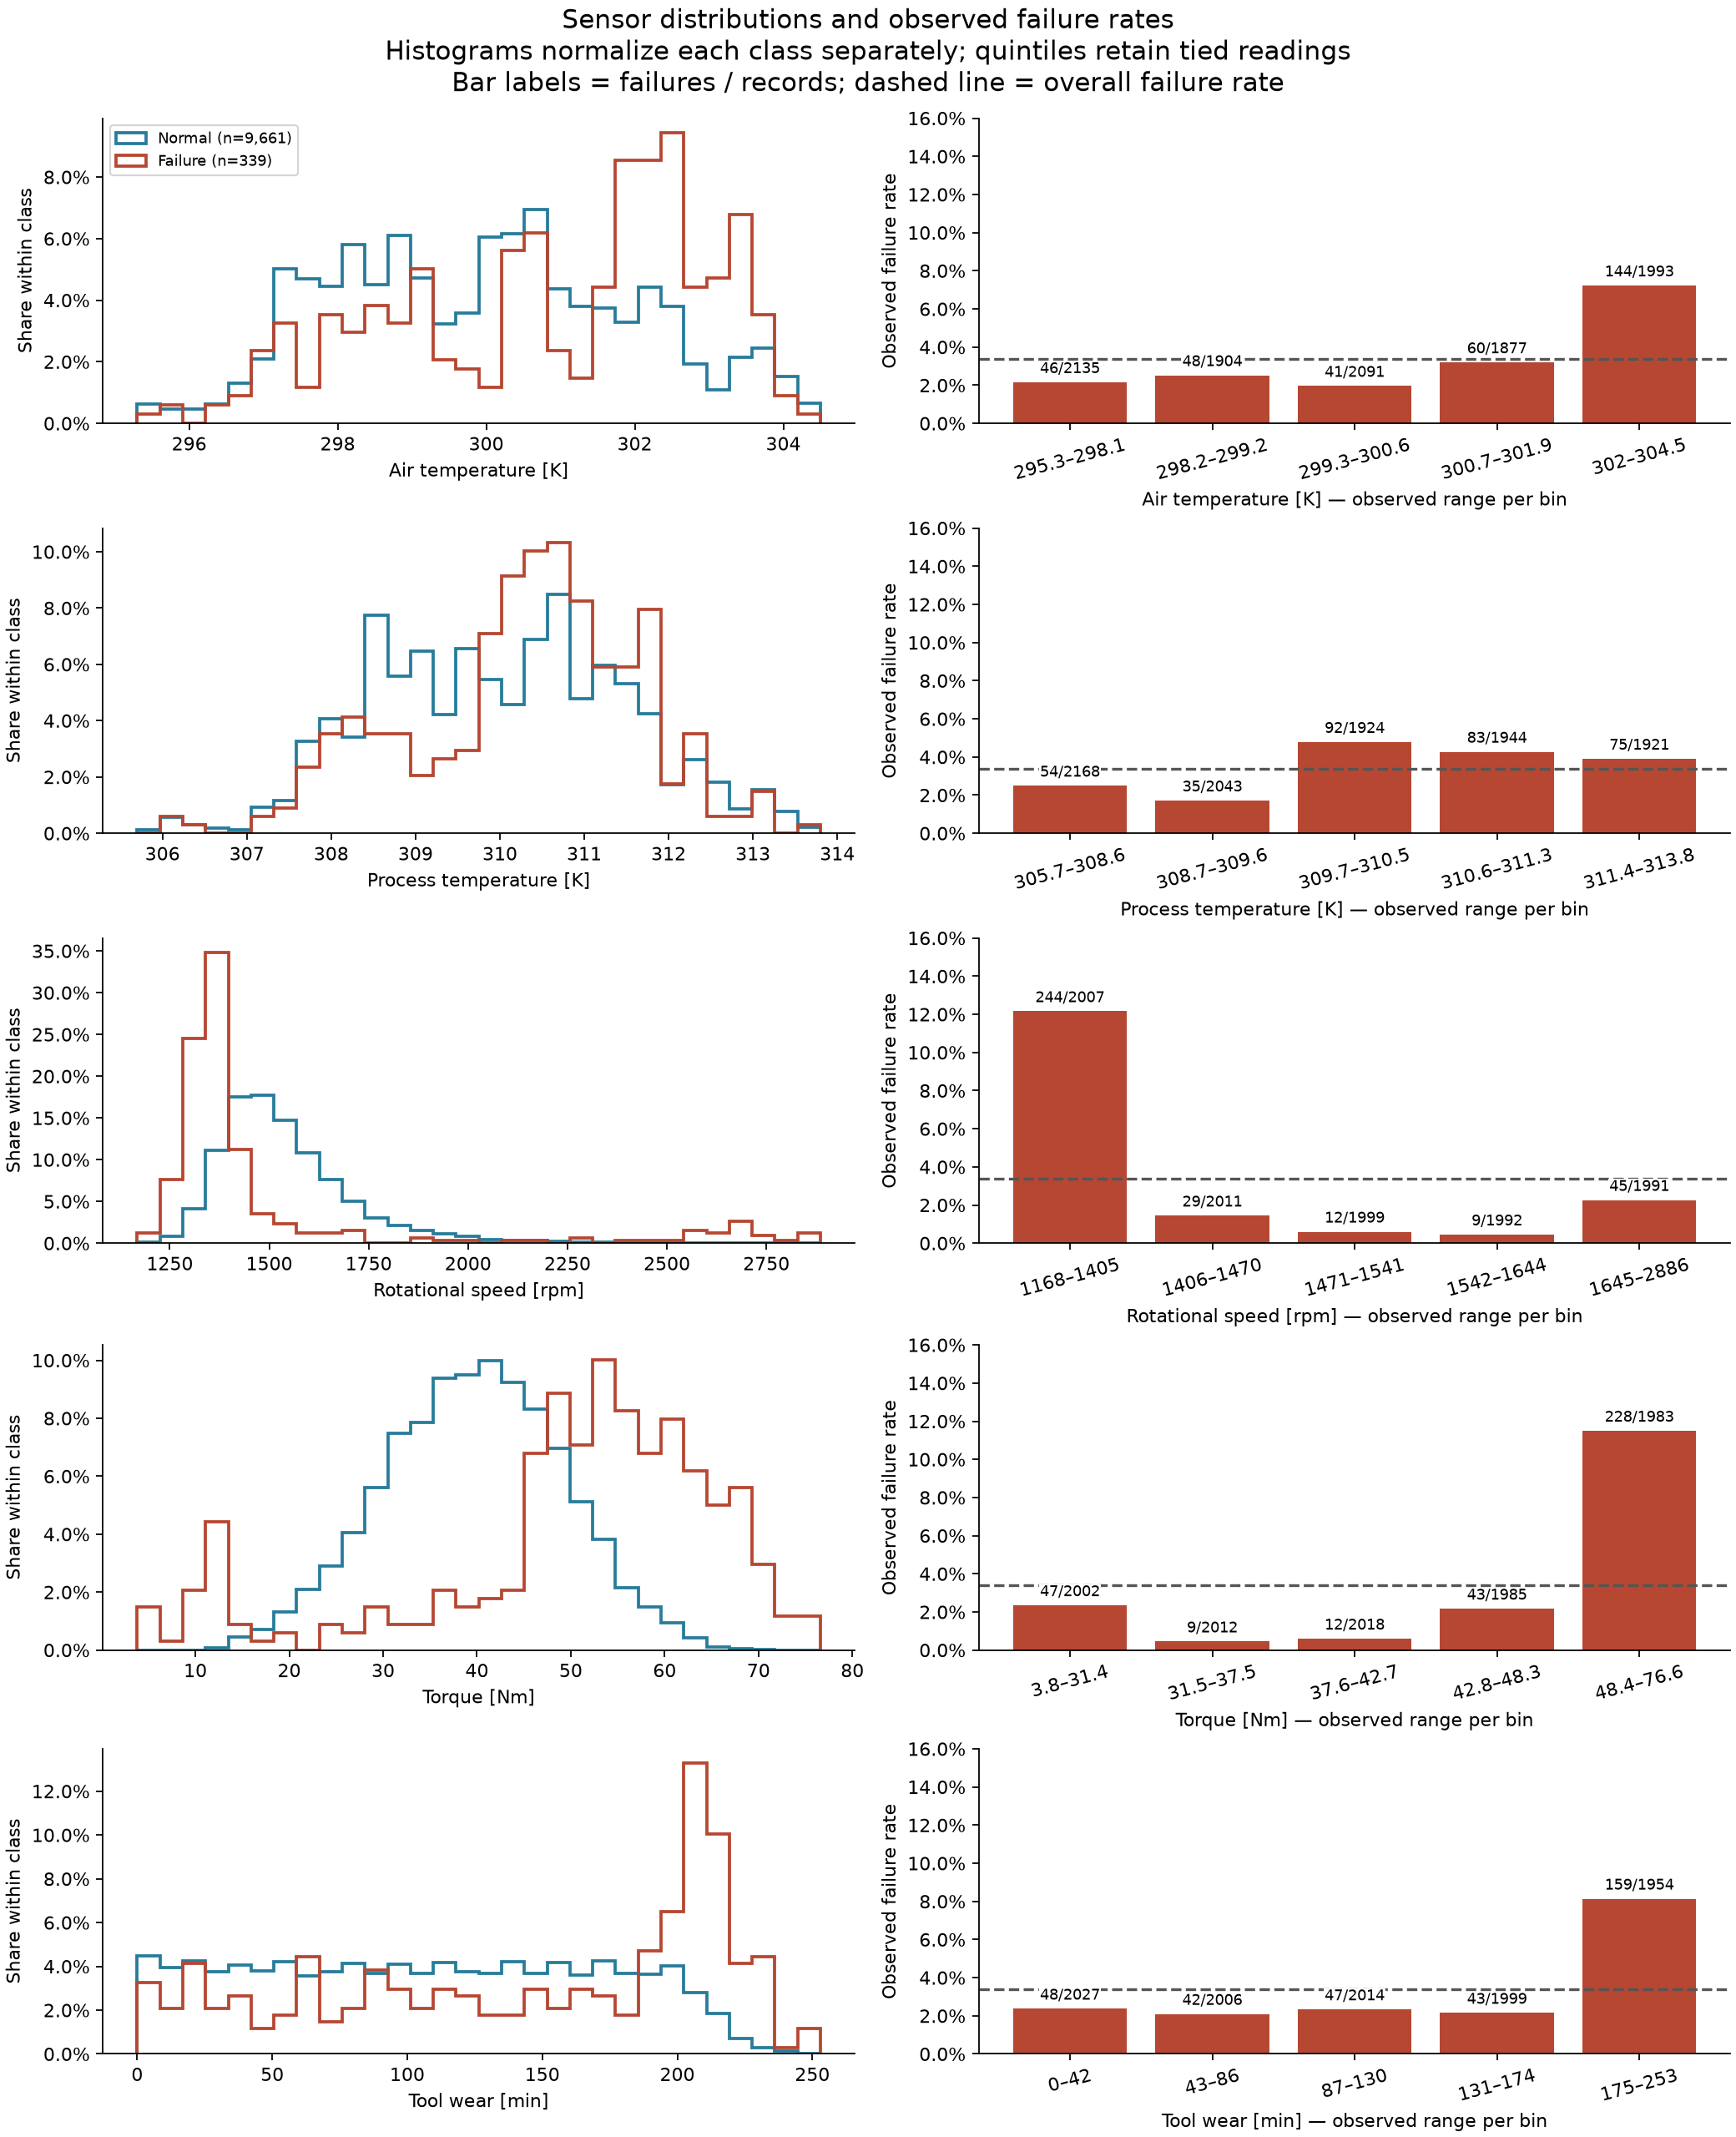

In [17]:
with plt.rc_context({"font.family": "DejaVu Sans", "axes.spines.top": False, "axes.spines.right": False, "font.size": 10}):
    plot_sensors(frame, summary)
display(Image(filename=str(FIGURE_DIR / "eda_sensors.png")))

Histogram weights normalize each class separately. Bar labels show failures/records; dashed lines show overall prevalence. Quintile failure rates reach 12.16% for the lowest speed group, 11.50% for the highest torque group, and 8.14% for the highest wear group. These bins are not operational thresholds. Of 69 torque readings outside the IQR fences, 62 are failures: retain extreme readings.

### Correlations

In [18]:
def plot_correlations(summary: dict) -> None:
    correlations = pd.DataFrame(summary["pearson_correlations"])
    figure, ax = plt.subplots(figsize=(9, 7), layout="constrained")
    heatmap = ax.imshow(correlations, vmin=-1, vmax=1, cmap="RdBu_r")
    labels = [*SENSOR_NAMES, "Machine failure"]
    ax.set_xticks(range(6), labels, rotation=35, ha="right")
    ax.set_yticks(range(6), labels)
    for row in range(6):
        for column in range(6):
            value = correlations.iloc[row, column]
            ax.text(column, row, f"{value:.2f}", ha="center", va="center", color="white" if abs(value) > 0.65 else "black")
    ax.set_title("Pearson correlations\nMarginal linear associations; failure-state flags and identifiers excluded", pad=18)
    figure.colorbar(heatmap, ax=ax, label="Correlation")
    save_figure(figure, "eda_correlations")

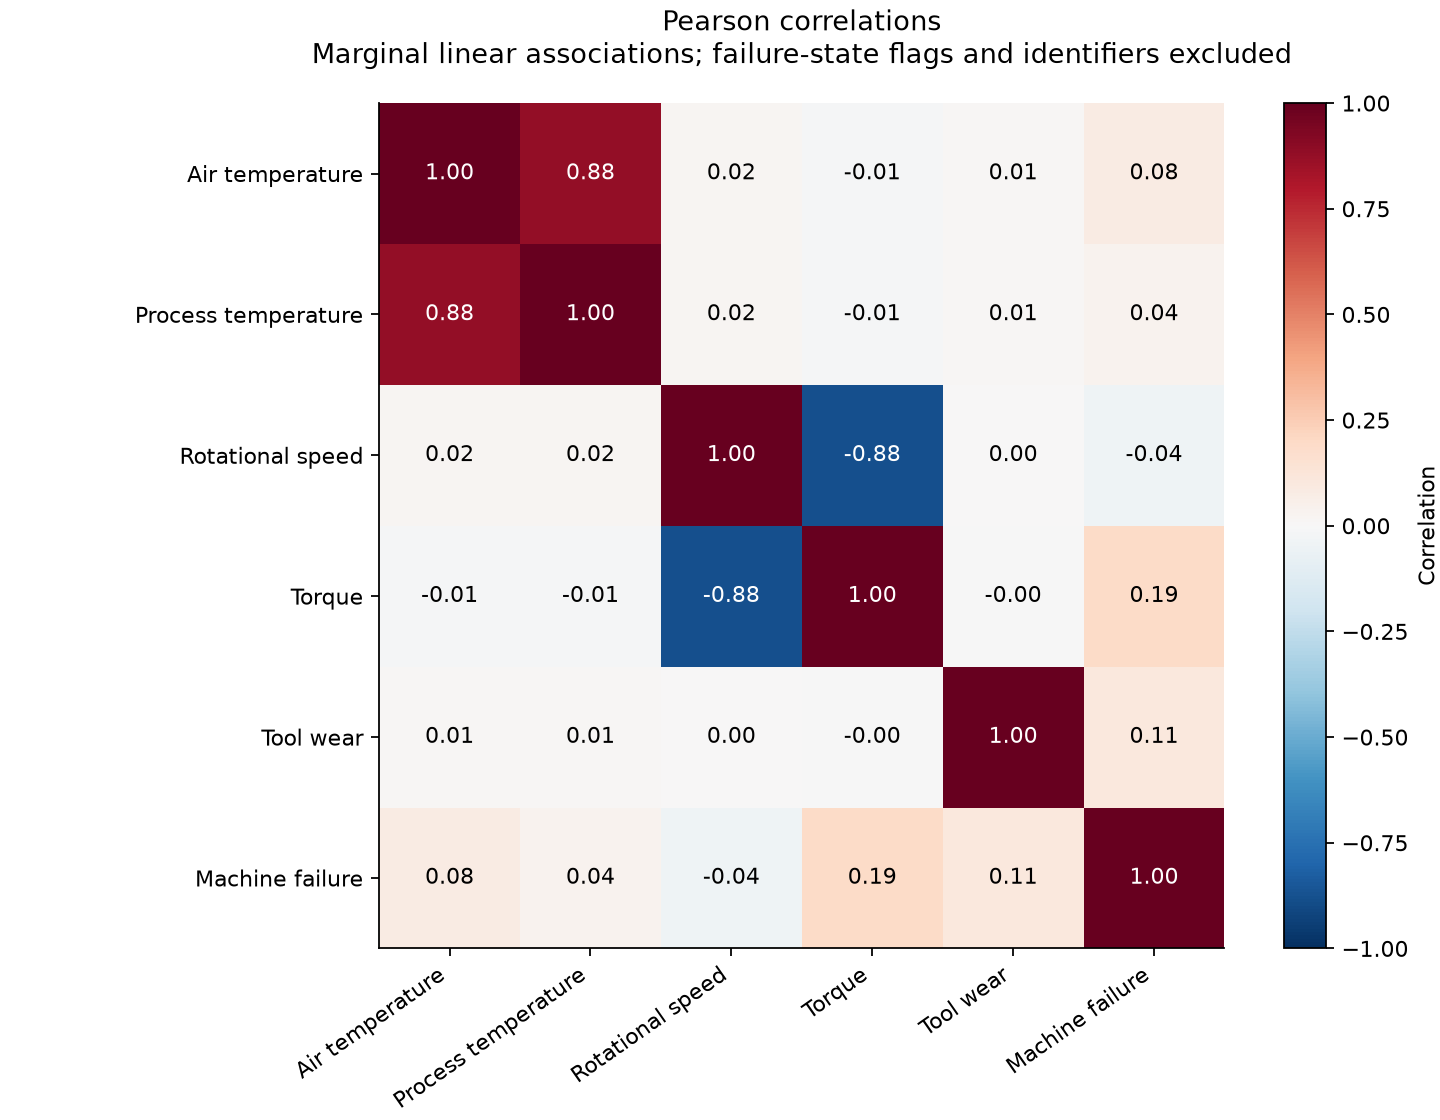

In [19]:
with plt.rc_context({"font.family": "DejaVu Sans", "axes.spines.top": False, "axes.spines.right": False, "font.size": 10}):
    plot_correlations(summary)
display(Image(filename=str(FIGURE_DIR / "eda_correlations.png")))

Air and process temperatures correlate at 0.8761; torque and speed at −0.8750. Speed has weak linear correlation with the target despite pronounced nonlinear differences. Do not discard a sensor merely because its marginal Pearson correlation is small.

### Sensor interactions

In [20]:
def plot_interactions(frame: pd.DataFrame) -> None:
    figure, axes = plt.subplots(1, 2, figsize=(13, 5.5), layout="constrained")
    figure.suptitle("Sensor relationships by observed failure status\nAll records shown; color indicates the supplied binary label", fontsize=15)
    temperature_gap = frame["Process temperature [K]"] - frame["Air temperature [K]"]
    for label, color, name in ((0, NORMAL_COLOR, "Normal"), (1, FAILURE_COLOR, "Failure")):
        mask = frame[TARGET_COLUMN] == label
        style = {"color": color, "alpha": 0.14 if label == 0 else 0.7, "s": 8 if label == 0 else 15, "label": name, "edgecolors": "none"}
        axes[0].scatter(frame.loc[mask, "Rotational speed [rpm]"], frame.loc[mask, "Torque [Nm]"], **style)
        axes[1].scatter(frame.loc[mask, "Rotational speed [rpm]"], temperature_gap[mask], **style)
    axes[0].set(xlabel="Rotational speed [rpm]", ylabel="Torque [Nm]")
    axes[1].set(xlabel="Rotational speed [rpm]", ylabel="Process − air temperature [K]")
    for ax in axes:
        ax.legend()
    save_figure(figure, "eda_interactions")

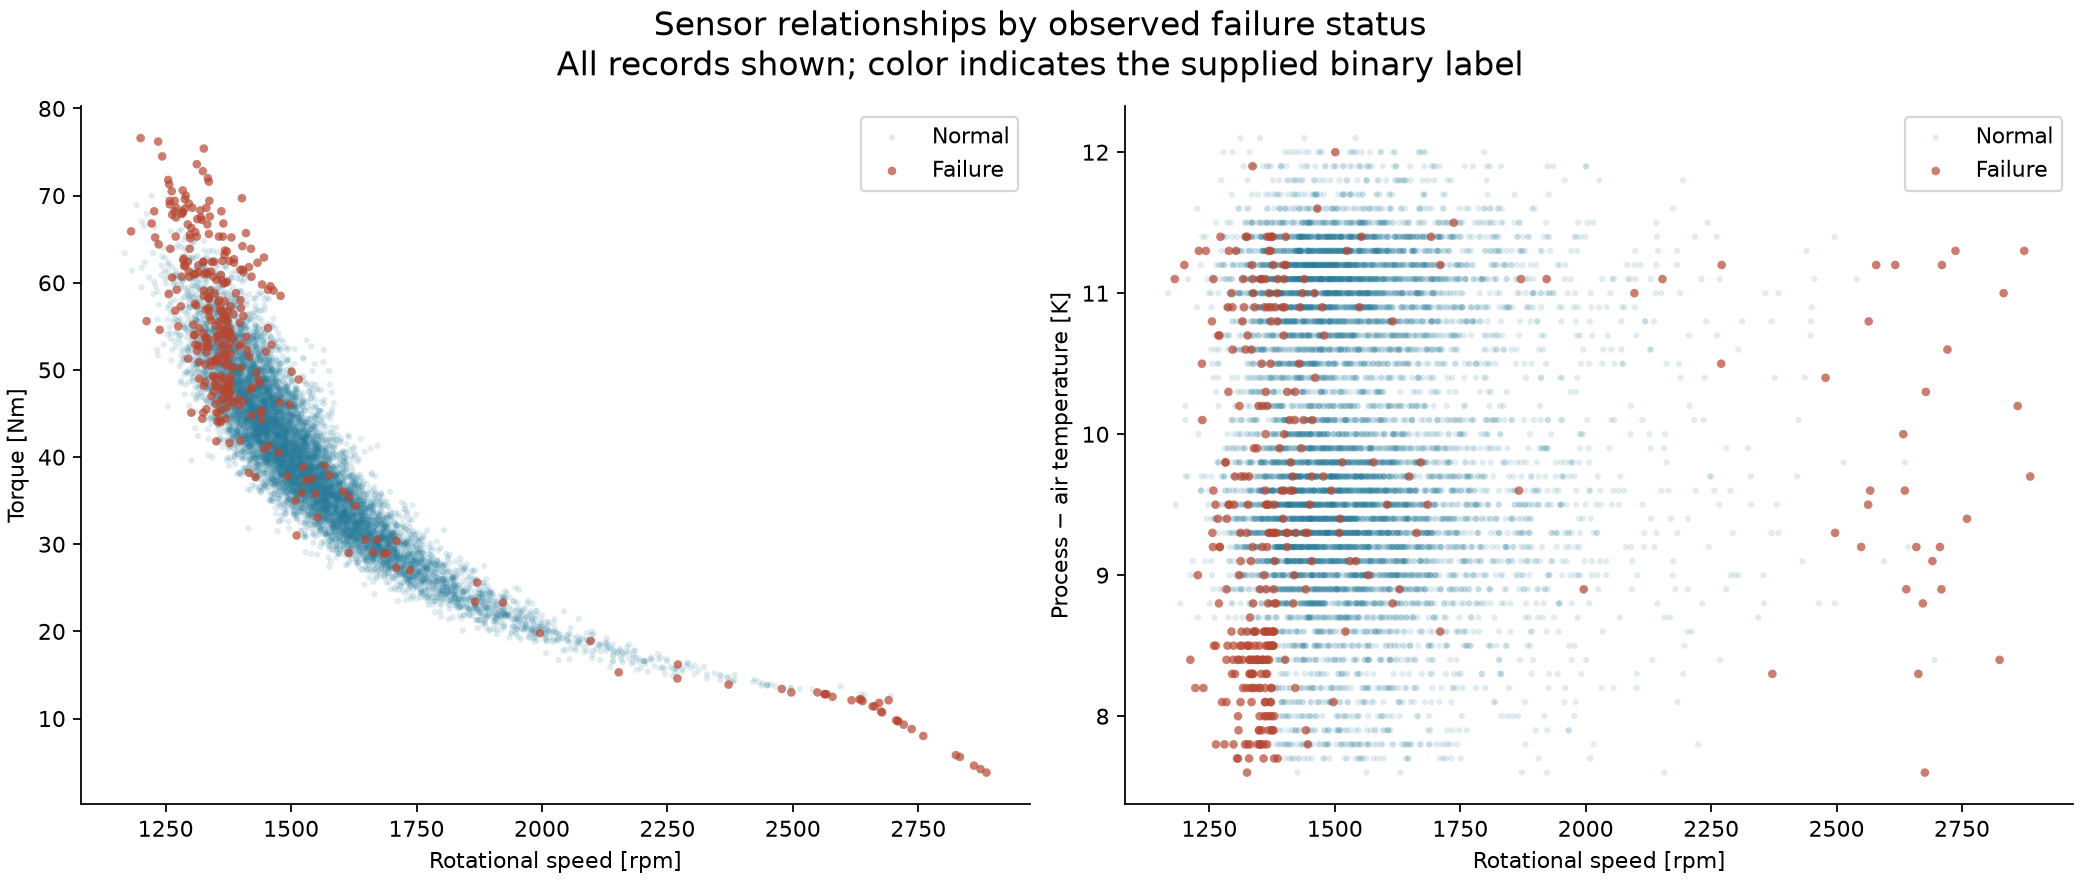

In [21]:
with plt.rc_context({"font.family": "DejaVu Sans", "axes.spines.top": False, "axes.spines.right": False, "font.size": 10}):
    plot_interactions(frame)
display(Image(filename=str(FIGURE_DIR / "eda_interactions.png")))

All records appear in the scatter plots. Failure observations occur along both tails of the speed–torque relationship and at low speeds with small temperature gaps. The process-minus-air gap is calculated only for visualization; it is not added to the model input schema.

### Ordering effects

In [22]:
def plot_order(frame: pd.DataFrame, summary: dict) -> None:
    figure, axes = plt.subplots(3, 1, figsize=(13, 10), layout="constrained")
    figure.suptitle("CSV row order reveals dependence and changing failure prevalence\nRow position is not a verified timestamp", fontsize=15)
    positions = np.arange(1, len(frame) + 1)
    for column, color in zip(NUMERIC_COLUMNS[:2], (NORMAL_COLOR, "#795aa6")):
        axes[0].plot(positions, frame[column], color=color, linewidth=0.7, label=column)
    axes[0].set(ylabel="Temperature [K]", xlabel="CSV row position (1-based)")
    axes[0].legend(fontsize=9)
    blocks = pd.DataFrame(summary["row_blocks"])
    bars = axes[1].bar(blocks["block"], blocks["failure_rate"], color=FAILURE_COLOR)
    axes[1].bar_label(bars, labels=[f"{r.failures}/{r.records}" for r in blocks.itertuples()], padding=3, fontsize=8, bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.5})
    axes[1].axhline(summary["overall_failure_rate"], color="#555555", linestyle="--", label="Overall rate")
    axes[1].set(xticks=blocks["block"], xlabel="Consecutive blocks of 1,000 rows", ylabel="Observed failure rate", ylim=(0, 0.17))
    axes[1].yaxis.set_major_formatter(PercentFormatter(1))
    axes[1].legend(fontsize=9)
    correlations = list(summary["lag_one_correlations_in_csv_order"].values())
    bars = axes[2].barh(SENSOR_NAMES, correlations, color=NORMAL_COLOR)
    axes[2].bar_label(bars, fmt="%.4f", padding=4)
    axes[2].set(xlim=(-0.05, 1.15), xlabel="Pearson correlation between adjacent rows")
    save_figure(figure, "eda_row_order")

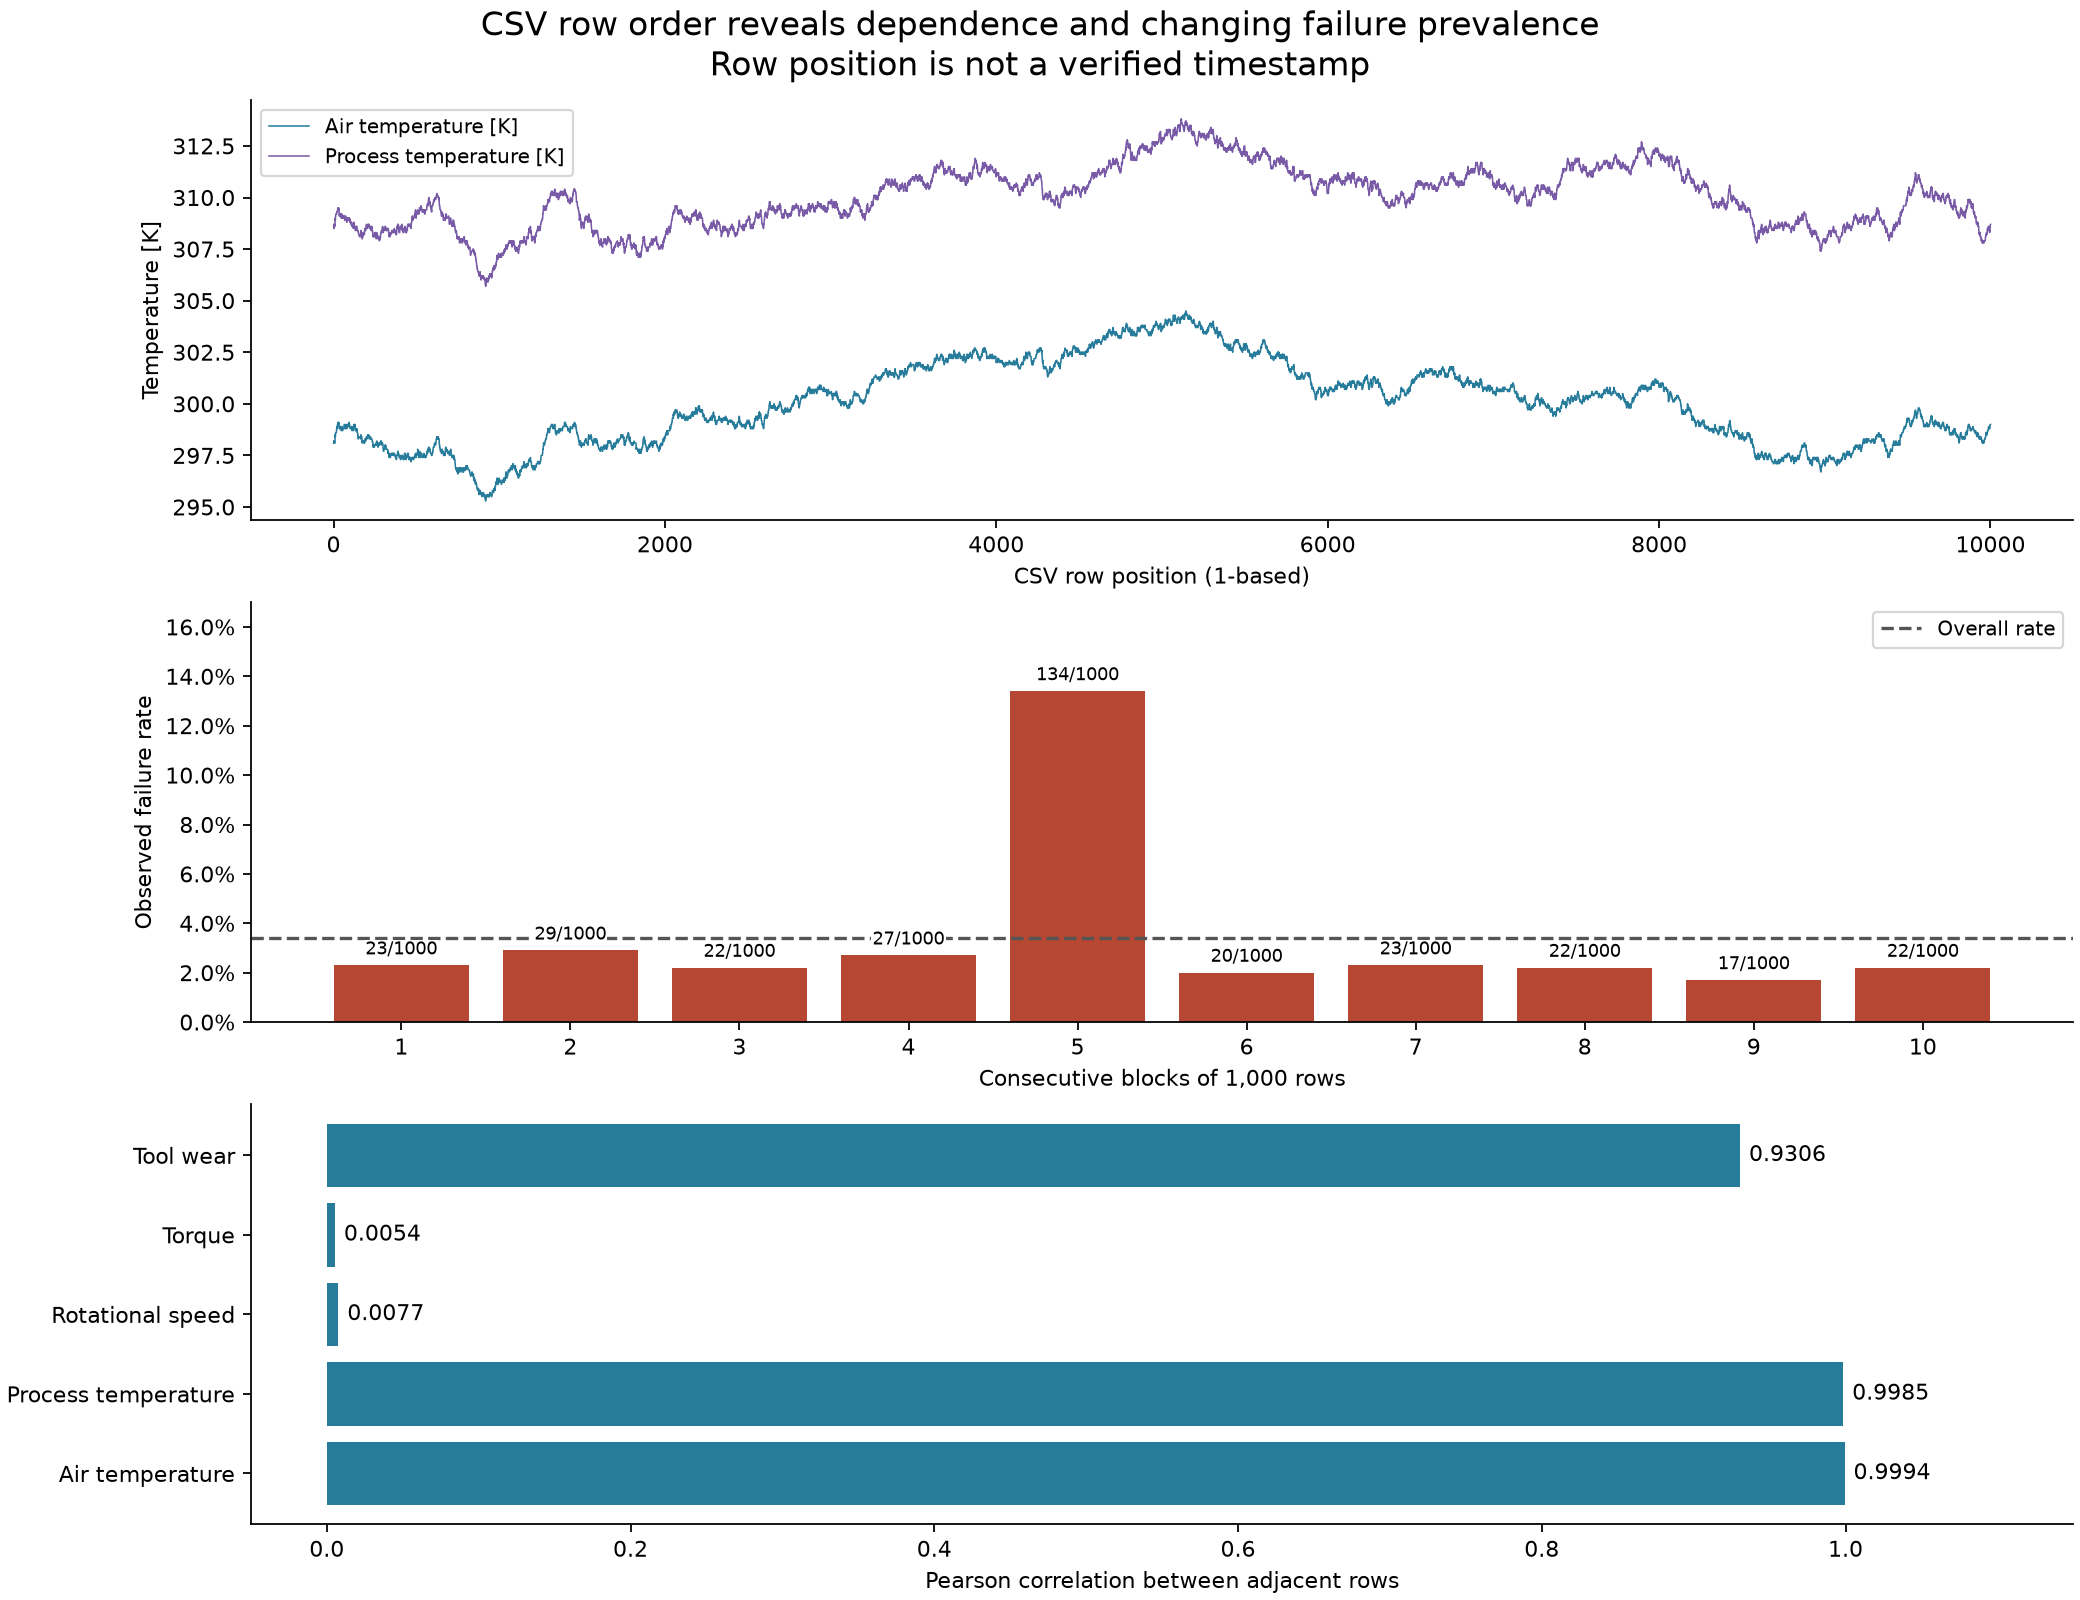

In [23]:
with plt.rc_context({"font.family": "DejaVu Sans", "axes.spines.top": False, "axes.spines.right": False, "font.size": 10}):
    plot_order(frame, summary)
display(Image(filename=str(FIGURE_DIR / "eda_row_order.png")))

Adjacent air/process temperature correlations exceed 0.998. Rows 4,001–5,000 contain 134 failures and 108 of 115 HDF flags. A random split can spread related regimes across partitions; a tail-only holdout contains no HDF positives. Later evaluation needs a documented order-aware robustness protocol and support checks, without treating CSV order as verified chronology.

### Failure label frequencies and overlap

In [24]:
def plot_failure_types(summary: dict) -> None:
    support = pd.DataFrame(summary["failure_label_support"]).T
    overlap = pd.DataFrame(summary["failure_label_cooccurrence"])
    figure, axes = plt.subplots(1, 2, figsize=(12, 5.5), layout="constrained")
    figure.suptitle("Failure flags are rare, overlapping labels", fontsize=16)
    axes[0].bar(support.index, support["with_primary_failure"], color=FAILURE_COLOR, label="Primary target = 1")
    bars = axes[0].bar(support.index, support["without_primary_failure"], bottom=support["with_primary_failure"], color=NORMAL_COLOR, label="Primary target = 0")
    axes[0].bar_label(bars, labels=support["positive_flags"].astype(str), padding=4)
    axes[0].set(ylabel="Positive flag count", ylim=(0, 150), title="Counts by primary target")
    axes[0].legend(fontsize=9)
    heatmap = axes[1].imshow(overlap, cmap="Blues")
    axes[1].set_xticks(range(5), FAILURE_COLUMNS)
    axes[1].set_yticks(range(5), FAILURE_COLUMNS)
    axes[1].set_title("Pairwise co-occurrence\nDiagonal = total positive flags")
    for row in range(5):
        for column in range(5):
            count = overlap.iloc[row, column]
            axes[1].text(column, row, str(count), ha="center", va="center", color="white" if count > 65 else "black")
    figure.colorbar(heatmap, ax=axes[1], label="Records")
    save_figure(figure, "eda_failure_types")

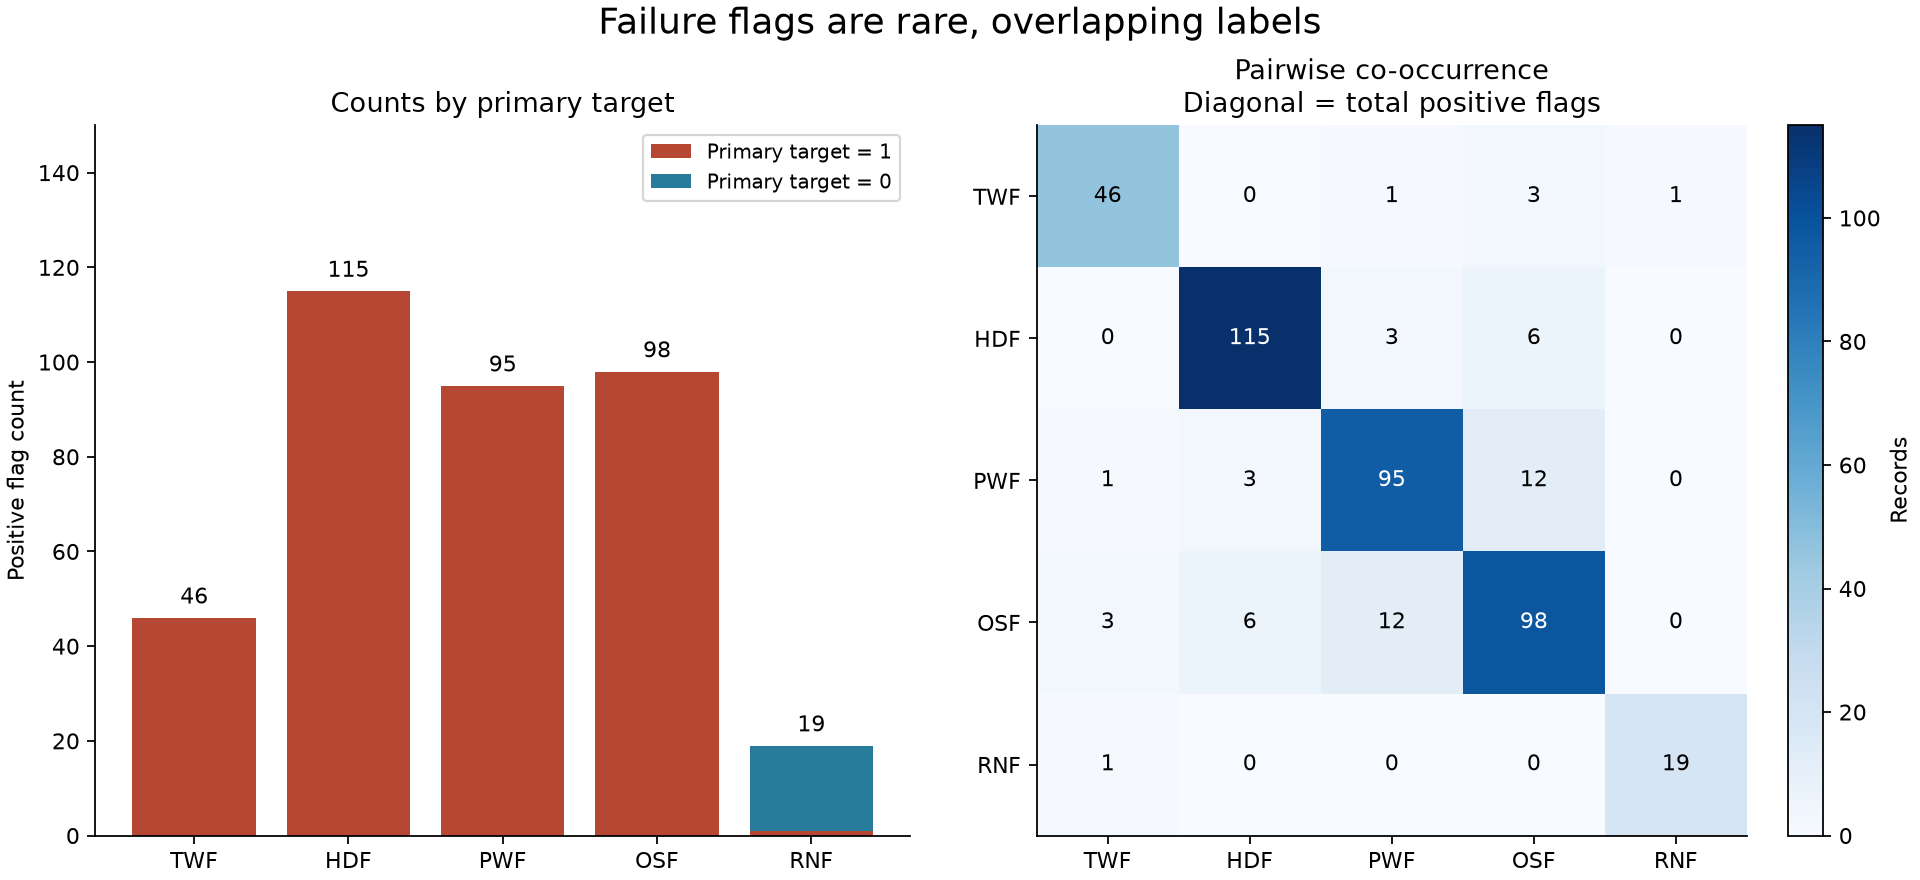

In [25]:
with plt.rc_context({"font.family": "DejaVu Sans", "axes.spines.top": False, "axes.spines.right": False, "font.size": 10}):
    plot_failure_types(summary)
display(Image(filename=str(FIGURE_DIR / "eda_failure_types.png")))

The matrix counts all pairwise overlaps, including rows with three active flags. PWF and OSF co-occur in 12 records. RNF has 19 positives but only one also has a positive primary target. Do not merge the flags into a multiclass target or relabel the binary target.

## 6. Data preservation checks

In [26]:
pd.testing.assert_frame_equal(frame, original_frame)
assert hashlib.sha256(RAW_DATA_PATH.read_bytes()).hexdigest() == source_hash_before
assert sum(summary["target_counts"].values()) == len(frame)
assert sum(item["failures"] for item in summary["row_blocks"]) == int(frame[TARGET_COLUMN].sum())
print("Raw CSV unchanged; data frame preserved; counts reconcile.")

Raw CSV unchanged; data frame preserved; counts reconcile.


## Decisions and limitations

Retain six original candidate inputs, every observation, and original labels. Full-dataset EDA exposes aggregate information about future test rows, so later internal test results must disclose that exploratory exposure. Freeze partitions before model development and keep them out of fitting, tuning, threshold selection, and feature selection. A fresh external dataset would provide stronger independent confirmation.

The findings are descriptive; they do not establish causation, industrial effectiveness, or a future warning horizon. See `reports/milestone_2.md` for the full interpretation and `02_validation_checks.ipynb` for automated checks.

**Stop here. Next milestone: reusable preprocessing and a documented train/validation/test strategy.**